# Lightweight Grid Calibration Notebook

This notebook compares synthetic and real grids using the exported CSV metrics only.

It keeps status-stratified diagnostics at the top as a check, but uses the full synthetic export for the main representativeness comparison. Normalized Wasserstein distance is the primary score, and feeder count is shown together with buildings per feeder.

In [12]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = (project_root / ".." / "..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

comparison_helpers = importlib.import_module("pylovo.analysis.comparison_helpers")
comparison_helpers = importlib.reload(comparison_helpers)
comparison_notebook = importlib.import_module("validation.grid_comparison.comparison_notebook")
comparison_notebook = importlib.reload(comparison_notebook)

DEFAULT_LABELS = comparison_notebook.DEFAULT_LABELS
DEFAULT_METRICS = comparison_notebook.DEFAULT_METRICS
load_and_render_overview = comparison_notebook.load_and_render_overview
plot_boxplot_overview = comparison_notebook.plot_boxplot_overview
plot_metric_kde_diagonal = comparison_notebook.plot_metric_kde_diagonal
show_cable_type_comparison = comparison_notebook.show_cable_type_comparison
show_distribution_selector = comparison_notebook.show_distribution_selector
show_wasserstein_summary = comparison_notebook.show_wasserstein_summary

METRICS_DIR = project_root / "validation" / "metrics"
METRICS = list(DEFAULT_METRICS)
LABELS = dict(DEFAULT_LABELS)
PALETTE = {"Synthetic": "steelblue", "Real": "crimson"}
MIN_CABLE_SEGMENTS = 100
PLZ = 91301
REAL_GRID_DIR = None

In [13]:
notebook_data = load_and_render_overview(
    metrics_dir=METRICS_DIR,
    metrics=METRICS,
    labels=LABELS,
)

### Data Inputs

,source,path,rows
0,Synthetic,/home/breveron/git/github/pylovo/validation/me...,171
1,Real,/home/breveron/git/github/pylovo/validation/me...,138


### Status-Stratified Diagnostics

,power_flow_status,count
0,converged,113
1,voltage_violation,58


,power_flow_status,synthetic_n,real_n,mean_normalized_wasserstein,median_normalized_wasserstein,worst_metric,worst_normalized_wasserstein
0,converged,113,138,0.4449,0.4460,graph_resistance,0.5200
1,voltage_violation,58,138,0.3343,0.3776,graph_resistance,0.4197


### Primary Wasserstein Score

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,max_trafo_distance,171,138,0.0577,0.1910,good
1,graph_length,171,138,0.5668,0.2077,good
2,transformer_mva,171,138,0.0538,0.2340,good
3,graph_resistance,171,138,0.2745,0.2528,acceptable
4,avg_trafo_distance,171,138,0.0362,0.2697,acceptable
5,feeder_lines,171,138,2.2034,0.2754,acceptable


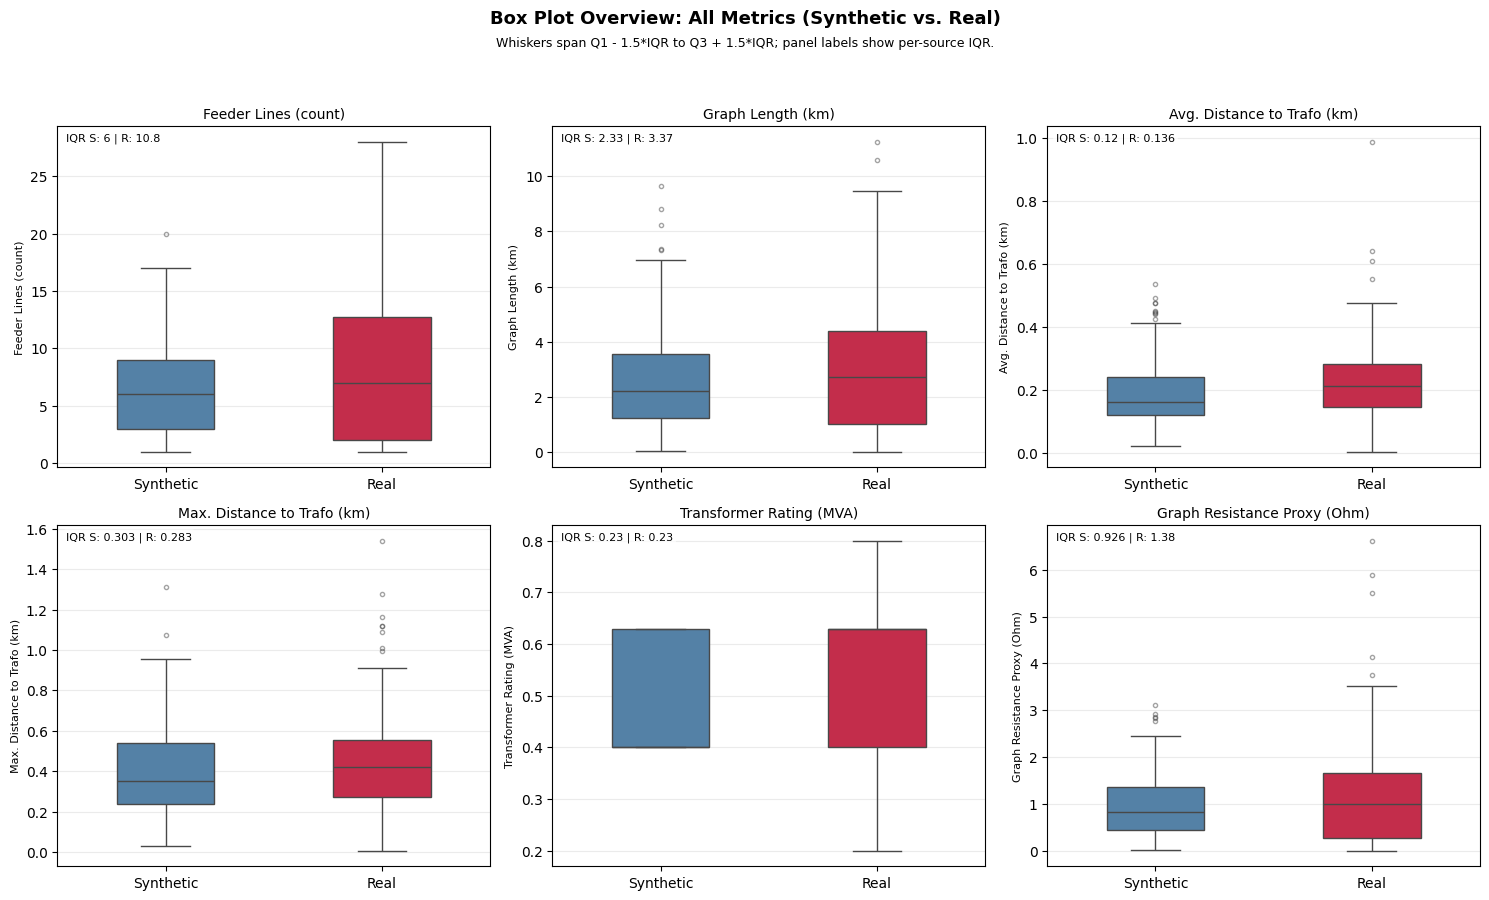

In [10]:
_ = plot_boxplot_overview(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    title="Box Plot Overview: All Metrics (Synthetic vs. Real)",
)

In [4]:
show_distribution_selector(
    notebook_data.df_all,
    notebook_data.metrics,
    notebook_data.labels,
    plot_type="box",
    height=520,
)

interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'graph_length', 'avg_trafo_d…

In [5]:
show_distribution_selector(
    notebook_data.df_all,
    notebook_data.metrics,
    notebook_data.labels,
    plot_type="violin",
    height=550,
    width=700,
)

interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'graph_length', 'avg_trafo_d…

In [12]:
_ = show_cable_type_comparison(
    PLZ,
    real_grid_dir=REAL_GRID_DIR,
    min_segment_count=MIN_CABLE_SEGMENTS,
 )

Showing cable types with more than 100 weighted line segments across real and synthetic grids. `segment_count` counts every in-service `net.line` segment between modeled nodes; parallel circuits contribute via their `parallel` multiplier, so this is not a whole-feeder count.

,std_type,source,segment_count,total_length_km,impedance_ohm_per_km
0,NS-Leitungstyp_fiktiv,Real,1152.0,14.4860,0.0000
1,NYY-J 3x150SM 0.6/1kV,Real,2075.0,54.8990,0.1453
2,NYY-J 4x120,Real,701.0,21.9430,0.1735
3,NAYY_4_185,Synthetic,716.0,15.8124,0.1825
4,NAYY 4x185SE 0.6/1kV,Real,1168.0,44.0630,0.1836
5,NYY-J 3x95SM 0.6/1kV,Real,1011.0,25.1140,0.2080
6,NAYBY 4x150sm 0.6/1kV,Real,122.0,3.7080,0.2197
7,NAYY 4x150SE 0.6/1kV,Real,497.0,14.9520,0.2218
8,NAYY_4_150,Synthetic,602.0,10.9104,0.2229
9,NAYY_4_120,Synthetic,9719.0,196.9998,0.2388


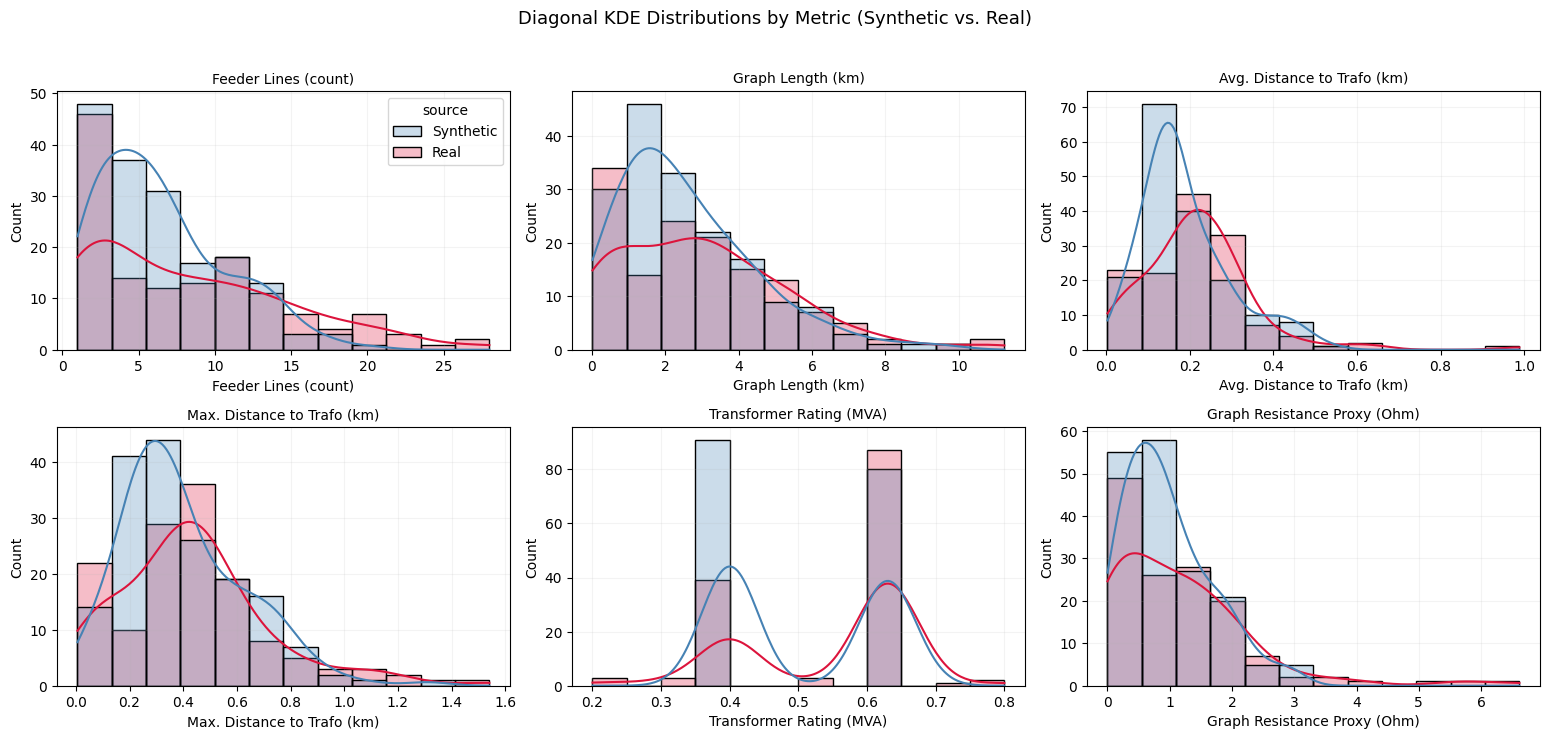

In [7]:
_ = plot_metric_kde_diagonal(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    show_hist_bars=True,
    bins=12,
    n_cols=3,
    title="Diagonal KDE Distributions by Metric (Synthetic vs. Real)",
)